# Naive Bayes :
Naive Bayes is a probabilistic machine learning algorithm based on Bayes' Theorem. It is particularly useful for classification tasks and assumes that the features are independent of each other (hence "naive"). Despite this assumption, it often performs well in practice, especially for text classification and spam filtering.

# Import necessary libraries

In [277]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
from skopt import BayesSearchCV
from sklearn.pipeline import make_pipeline
from skopt.space import Categorical

In [278]:
X_train = pd.read_csv('x_train.csv', index_col=0)
X_test = pd.read_csv('x_test.csv', index_col=0)
y_train = pd.read_csv('y_train.csv', index_col=0)
y_test = pd.read_csv('y_test.csv', index_col=0)

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# Initialize the Bayes Naive model

- . Why Gaussian Distribution?
Continuous Data: Gaussian Naive Bayes is specifically designed for continuous data. It assumes that the data for each feature is distributed according to a Gaussian (normal) distribution.
Simplicity: The Gaussian distribution is mathematically simple to work with, as it only requires calculating the mean and variance for each feature.
Common in Real-World Data: Many real-world datasets approximately follow a normal distribution, making the Gaussian assumption reasonable in practice.

- Functions :

In [279]:
def regression_report(predicted, true):
    mse = mean_squared_error(true, predicted)
    mae = mean_absolute_error(true, predicted)
    r2 = r2_score(true, predicted)
    rmse = np.sqrt(mse)

    print("="*50)
    print("       Regression Performance Report")
    print("="*50)
    print(f"   Mean Squared Error: {mse:.3f}")
    print(f"   Mean Absolute Error: {mae:.3f}")
    print(f"   Root Mean Squared Error: {rmse:.3f}")
    print(f"   R2 Score: {r2:.3f}")
    print("="*50)

In [280]:
def plot_actual_predicted(true, predicted):
    true = np.ravel(true)
    predicted = np.ravel(predicted)

    plt.figure(figsize=(8,6))

    sns.scatterplot(x=true, y=predicted, alpha=0.7, edgecolors='k', label="Predictions")

    min_value, max_value = min(true.min(), predicted.min()), max(true.max(), predicted.max())
    plt.plot([min_value, max_value], [min_value, max_value], color="purple", linestyle='--', label="y = x")

    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("Actual vs Predicted values")
    plt.legend()
    plt.grid(True)


In [281]:
def histogram_residuals(true, predicted):
    residuals = true - predicted
    
    
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, bins=10, kde=True, color='blue') 
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Histogram of Residuals")
    plt.grid(True)
    plt.show()

In [282]:
def plot_residuals_vs_predicted(y_true, y_pred):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')  
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs. Predicted Plot")
    plt.grid(True)
    plt.show()

In [283]:
def plot_qq(residuals):
    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title("QQ Plot of Residuals")
    plt.grid(True)
    plt.show()


- Naive Bayes Regressor Model :

In [284]:
import numpy as np
from scipy.stats import norm

class GaussianNaiveBayesRegressor:
    def __init__(self, epsilon=1e-6):
        self.epsilon = epsilon
        self.class_means = None
        self.class_vars = None
        self.class_priors = None
        self.classes = None

    def fit(self, X, y):
        
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]

        self.class_means = np.zeros((n_classes, n_features))
        self.class_vars = np.zeros((n_classes, n_features))
        self.class_priors = np.zeros(n_classes)

        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            self.class_means[i, :] = X_c.mean(axis=0)
            self.class_vars[i, :] = np.var(X_c, axis=0) + self.epsilon 
            self.class_priors[i] = (X_c.shape[0] + self.epsilon) / (X.shape[0] + len(self.classes) * self.epsilon)

    def predict(self, X):

        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probs = np.zeros((n_samples, n_classes))

        for i, c in enumerate(self.classes):
            log_prior = np.log(self.class_priors[i])
            log_likelihood = -0.5 * np.sum(
                np.log(2. * np.pi * np.maximum(self.class_vars[i, :], self.epsilon)) +
                ((X - self.class_means[i, :]) ** 2) / np.maximum(self.class_vars[i, :], self.epsilon),
                axis=1
            )
            log_probs[:, i] = log_prior + log_likelihood

        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs) / np.exp(log_probs).sum(axis=1, keepdims=True)

        y_pred = np.zeros(n_samples)
        for i, c in enumerate(self.classes):
            y_pred += probs[:, i] * c

        return y_pred
    
    def get_params(self, deep=True):
        
        return {"epsilon": self.epsilon}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

- Train and evaluate the model

In [285]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GaussianNaiveBayesRegressor()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

regression_report(y_pred, y_test)


       Regression Performance Report
   Mean Squared Error: 0.539
   Mean Absolute Error: 0.425
   Root Mean Squared Error: 0.734
   R2 Score: 0.617


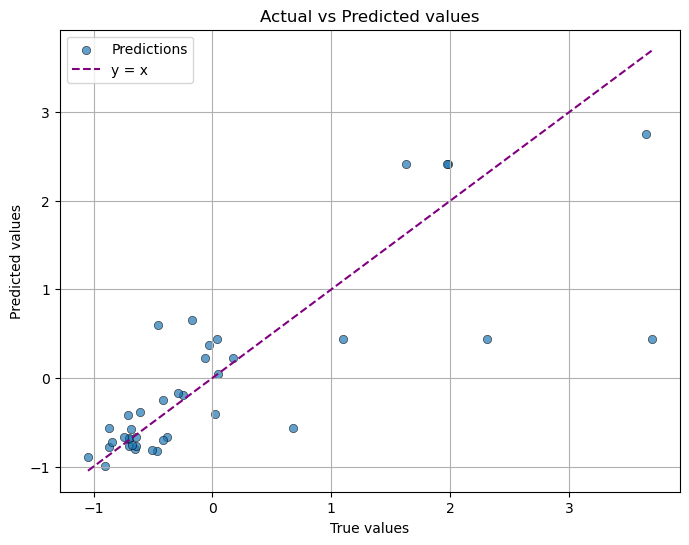

In [286]:
plot_actual_predicted(y_test, y_pred)

- Analysis : The points follow the our line with some deviations.

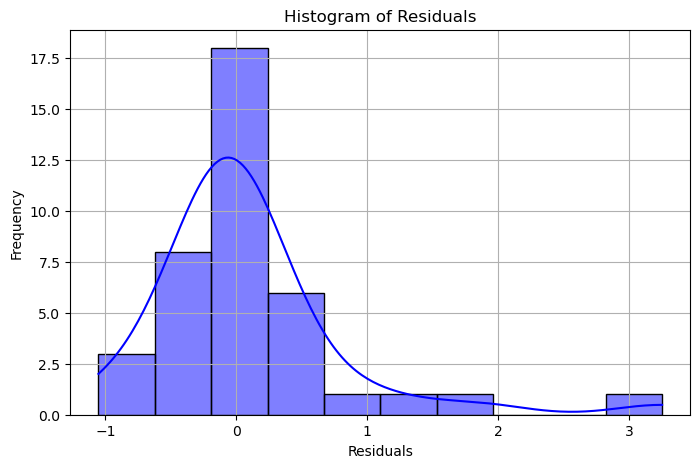

In [287]:
histogram_residuals(y_test, y_pred)

- The residuals are right-skewed, indicating the model tends to underestimate some values, with moderate variance and a few outliers, suggesting potential improvements through transformation, feature scaling, or a more robust model.

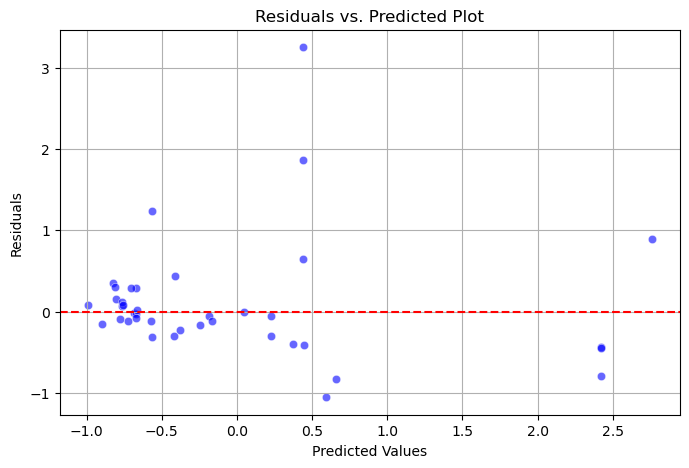

In [288]:
plot_residuals_vs_predicted(y_test, y_pred)

- Residuals vs. Predicted Plot: Residuals show patterns, indicating model bias or underfitting.

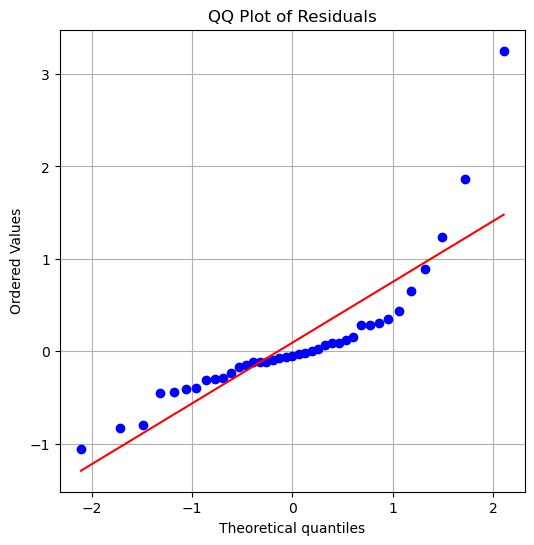

In [289]:
residuals = y_test - y_pred
plot_qq(residuals)

Residuals deviate from normality, especially at the tail

- Analyze the diffrent results :

According to the performance measures the model is not performing well because of the quite small R2 value and the relatively high value for the error measures.

We can also see that our model does follow the pattern we want but not with the amount we want so we it will need a bit of improvement


- Use hypermarameter tuning to improve the model by selecting the best epsilon value :

In [290]:
search_space = {
    'gaussiannaivebayesregressor__epsilon': Categorical([1e-6, 1e-5, 1e-4,
                                                        2e-4, 3e-4, 4e-4,
                                                        5e-4, 6e-4, 7e-4,
                                                        8e-4, 9e-4, 1e-3,
                                                        2e-3
                                                         ]), 
}

In [291]:
pipeline_bayes = make_pipeline(
    RobustScaler(),  
    GaussianNaiveBayesRegressor()  
)

bayes_search = BayesSearchCV(
    pipeline_bayes, 
    search_space, 
    n_iter=20,  
    cv=5, 
    scoring="neg_mean_squared_error", 
    n_jobs=-1
)

bayes_search.fit(X_train, y_train)

print(" Bayesian Search Best Parameters: ", bayes_search.best_params_)

best_model_bayes = bayes_search.best_estimator_

y_pred_bayes = best_model_bayes.predict(X_test)

regression_report(y_pred_bayes, y_test)


c:\Users\DELL\anaconda3\envs\DM_ENV\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.002] before, using random point [0.0005]
  warnings.warn(
c:\Users\DELL\anaconda3\envs\DM_ENV\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.0006] before, using random point [0.002]
  warnings.warn(
c:\Users\DELL\anaconda3\envs\DM_ENV\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.0009] before, using random point [0.0007]
  warnings.warn(


 Bayesian Search Best Parameters:  OrderedDict([('gaussiannaivebayesregressor__epsilon', 0.002)])
       Regression Performance Report
   Mean Squared Error: 0.147
   Mean Absolute Error: 0.274
   Root Mean Squared Error: 0.383
   R2 Score: 0.896


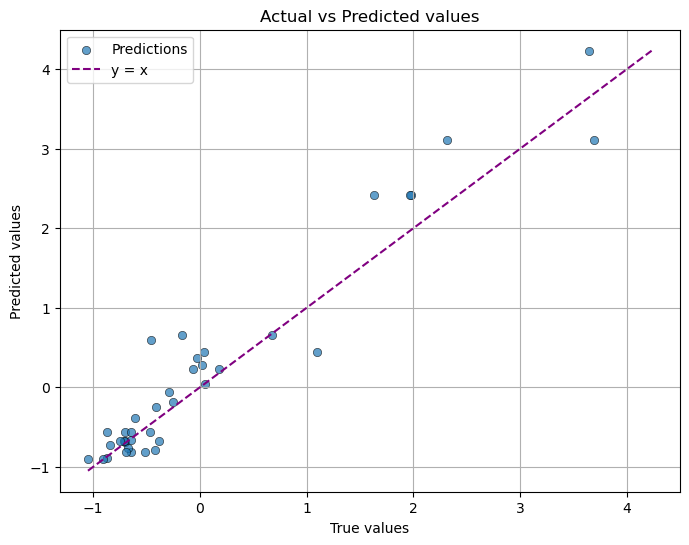

In [292]:
plot_actual_predicted(y_test, y_pred_bayes)

 Predictions align well with the diagonal line, but some outliers deviate from the pattern

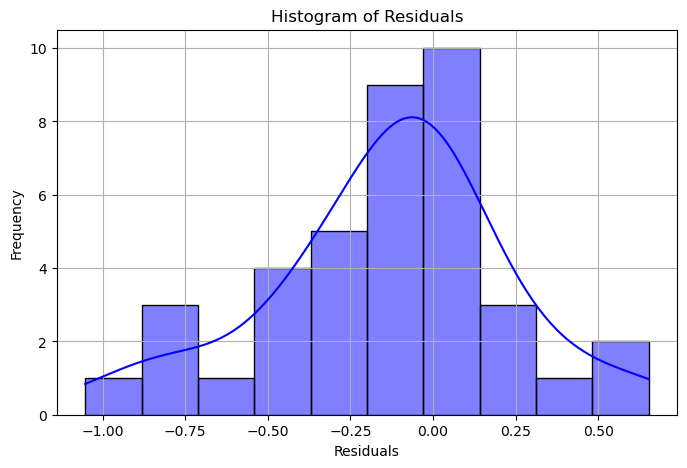

In [294]:
histogram_residuals(y_test, y_pred_bayes)

 Residuals are roughly centered around zero, but the distribution is slightly skewed.

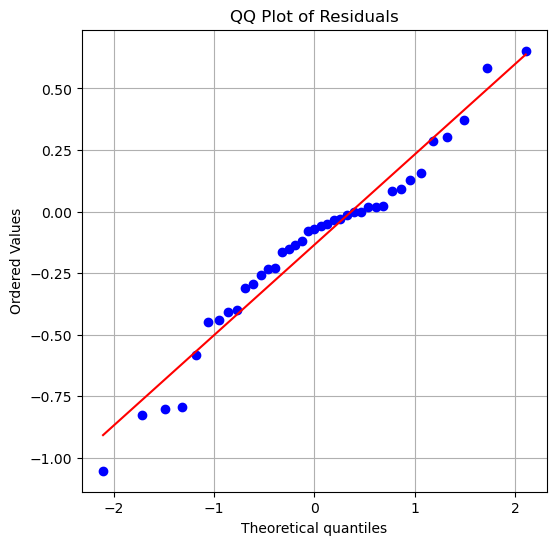

In [295]:
plot_qq(y_test - y_pred_bayes)

Residuals mostly follow the red line, but slight deviations at the tails suggest minor non-normality.

- Analyzing the improvement results :
We can see that our model has significantly improved in terms of performance measures and capturing the patterns 

- Comparision between predictions and actual price values

In [296]:
actual = y_test.flatten()
pred = y_pred_bayes.flatten()

comparaison = pd.DataFrame({
    "Actual price standardized: ":actual,
    "Predicted Price standardized: ":pred
})

print(comparaison)

    Actual price standardized:   Predicted Price standardized: 
0                      2.309677                        3.111803
1                     -0.470370                       -0.562641
2                     -0.168787                        0.656931
3                      1.980438                        2.419773
4                     -0.699736                       -0.562641
5                     -0.701178                       -0.686761
6                     -0.508511                       -0.812584
7                     -0.385308                       -0.671688
8                     -0.702882                       -0.674047
9                      0.020604                        0.276839
10                    -0.642198                       -0.665790
11                     0.673970                        0.656931
12                    -0.412832                       -0.247689
13                     3.646553                        4.228488
14                    -0.871564         

- Conclusion :
    - The overall Naive Bayes performance is good , with quite law error performance measures and a high R2 score.
    - The predictions comparisions are quite close with the presence of some outliers that we can see them present in our comparision.
    - Hyper paramter tuning helped in making the model perfomance noticebally 

